In [34]:
import numpy as np
import struct
import matplotlib.pyplot as plt


def load_images(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        rows, cols = struct.unpack(">II", f.read(8))

        data = np.fromfile(f, dtype = np.uint8)
        data = data.reshape(size, rows, cols)

        return data
    
images = load_images("train-images-idx3-ubyte")

print(images.shape)

(60000, 28, 28)


In [35]:
def load_labels(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype = np.uint8, count=size)
        return labels

labels = load_labels("train-labels-idx1-ubyte")

print(labels.shape)
print(labels[:10])

(60000,)
[5 0 4 1 9 2 1 3 1 4]


Text(0.5, 1.0, 'Label: 5')

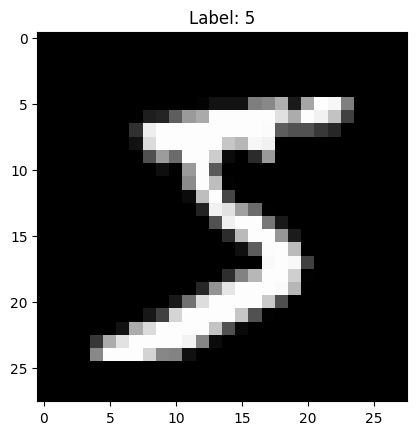

In [36]:
plt.imshow(images[0], cmap='gray')
plt.title(f"Label: {labels[0]}")

In [37]:
X = images.reshape(60000, 28*28)
X.shape

(60000, 784)

In [38]:
X = X/255.0

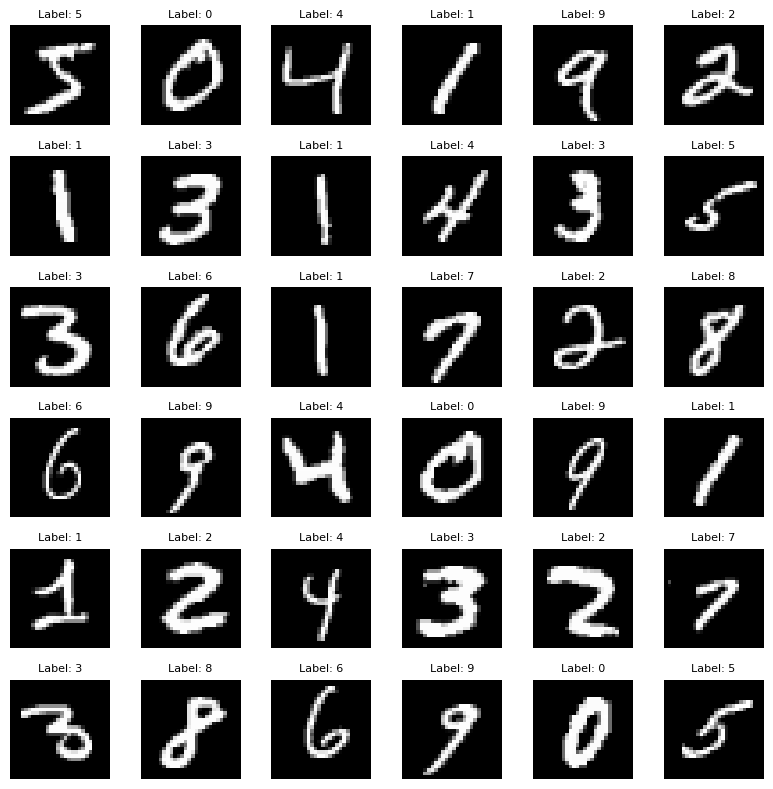

In [39]:
fig, ax = plt.subplots(6, 6, figsize =(8, 8))
for i, ax in enumerate(ax.flat):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {labels[i]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [40]:
X_train = X[:50000]
y_train = labels[:50000]

X_test = X[50000:]
y_test = labels[50000:]

In [41]:
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]


Y_train = one_hot(y_train)
Y_test = one_hot(y_test)

In [42]:
input_size = 784
hidden_size = 64
output_size = 10

In [43]:
def relu(x):
    return np.maximum(0, x)


def softmax(x):
    exp = np.exp(x - np.max(x, axis = 1, keepdims = True))
    return exp/ np.sum(exp, axis = 1, keepdims = True)


def compute_loss(Y_pred, Y_true):
    return -np.mean(np.sum(Y_true * np.log(Y_pred + 1e-8), axis =1))

In [44]:
np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

In [45]:
Z1 = X_train @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
Y_pred = softmax(Z2)

In [46]:
loss = compute_loss(Y_pred, Y_train)
loss

np.float64(2.3026802115722314)

In [47]:
epochs = 2000
learning_rate = 0.1
for epoch in range(epochs):

    #Forward
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    Y_pred = softmax(Z2)

    # Loss
    loss = compute_loss(Y_pred, Y_train)

    # Backward
    dZ2 = Y_pred - Y_train
    dW2 = A1.T @ dZ2 / X_train.shape[0]
    db2 = np.sum(dZ2, axis=0, keepdims=True) / X_train.shape[0]

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 *  (Z1 > 0)

    dW1 = X_train.T @ dZ1 / X_train.shape[0]
    db1 = np.sum(dZ1, axis =0, keepdims=True) / X_train.shape[0]

    # Update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 1 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 2.3027
Epoch 1, Loss: 2.3021
Epoch 2, Loss: 2.3015
Epoch 3, Loss: 2.3010
Epoch 4, Loss: 2.3004
Epoch 5, Loss: 2.2998
Epoch 6, Loss: 2.2991
Epoch 7, Loss: 2.2985
Epoch 8, Loss: 2.2978
Epoch 9, Loss: 2.2970
Epoch 10, Loss: 2.2963
Epoch 11, Loss: 2.2954
Epoch 12, Loss: 2.2946
Epoch 13, Loss: 2.2936
Epoch 14, Loss: 2.2926
Epoch 15, Loss: 2.2916
Epoch 16, Loss: 2.2904
Epoch 17, Loss: 2.2892
Epoch 18, Loss: 2.2878
Epoch 19, Loss: 2.2864
Epoch 20, Loss: 2.2849
Epoch 21, Loss: 2.2832
Epoch 22, Loss: 2.2814
Epoch 23, Loss: 2.2794
Epoch 24, Loss: 2.2773
Epoch 25, Loss: 2.2750
Epoch 26, Loss: 2.2726
Epoch 27, Loss: 2.2699
Epoch 28, Loss: 2.2670
Epoch 29, Loss: 2.2639
Epoch 30, Loss: 2.2605
Epoch 31, Loss: 2.2568
Epoch 32, Loss: 2.2529
Epoch 33, Loss: 2.2486
Epoch 34, Loss: 2.2440
Epoch 35, Loss: 2.2390
Epoch 36, Loss: 2.2337
Epoch 37, Loss: 2.2280
Epoch 38, Loss: 2.2218
Epoch 39, Loss: 2.2152
Epoch 40, Loss: 2.2081
Epoch 41, Loss: 2.2005
Epoch 42, Loss: 2.1924
Epoch 43, Loss: 2.183

In [48]:
y_pred = np.argmax(Y_pred, axis = 1)
y_true = np.argmax(Y_train, axis = 1)

In [49]:
def accuracy_test(preds, trues):
    return np.mean(preds == trues)

In [50]:
accuracy =  accuracy_test(y_pred, y_true)
print(f"Training Accuracy: {accuracy}")

Training Accuracy: 0.94228


In [51]:
Z1_test = X_test @ W1 + b1
A1_test = relu(Z1_test)

Z2_test = A1_test @ W2 + b2
Y_test_pred = softmax(Z2_test)

In [52]:
y_test_pred = np.argmax(Y_test_pred, axis = 1)

In [53]:
y_test_true = np.argmax(Y_test, axis = 1)

In [54]:
accuracy = accuracy_test(y_test_pred, y_test_true)
accuracy

np.float64(0.9439)

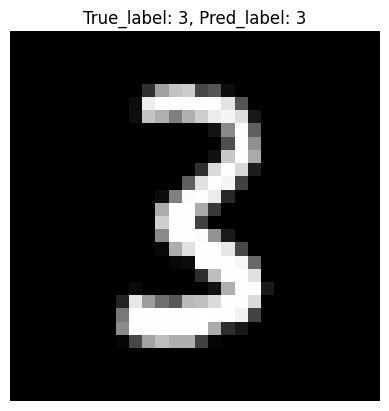

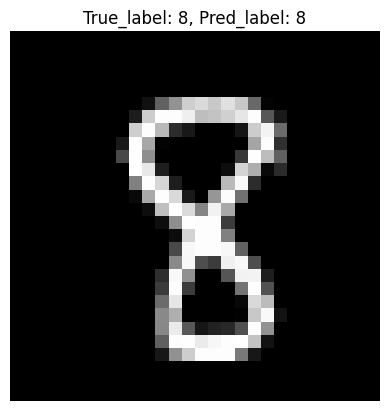

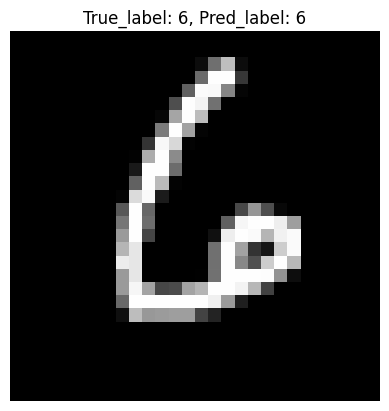

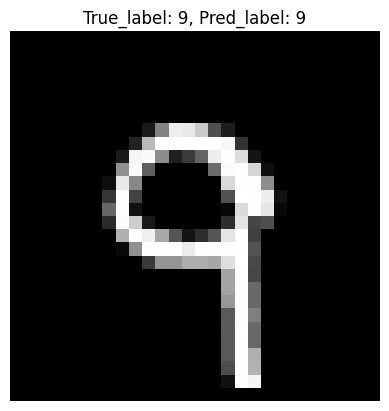

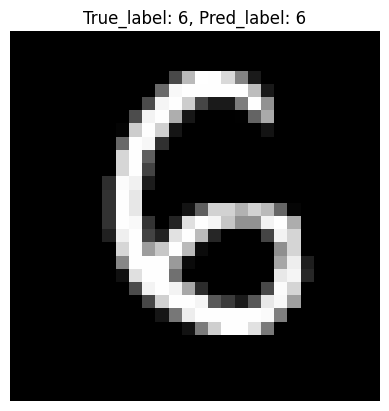

In [55]:
for i in range(5):
    fig, ax = plt.subplots()
    ax.imshow(X_test[i].reshape(28,28), cmap = 'gray')
    ax.set_title(f"True_label: {y_test_true[i]}, Pred_label: {y_test_pred[i]}")
    ax.axis("off")

In [56]:
cm = np.zeros((10,10), dtype=int)

for i in range(len(y_test_true)):
    true = int(y_test_true[i])
    pred = int(y_test_pred[i])
    cm[true, pred] += 1

In [57]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)


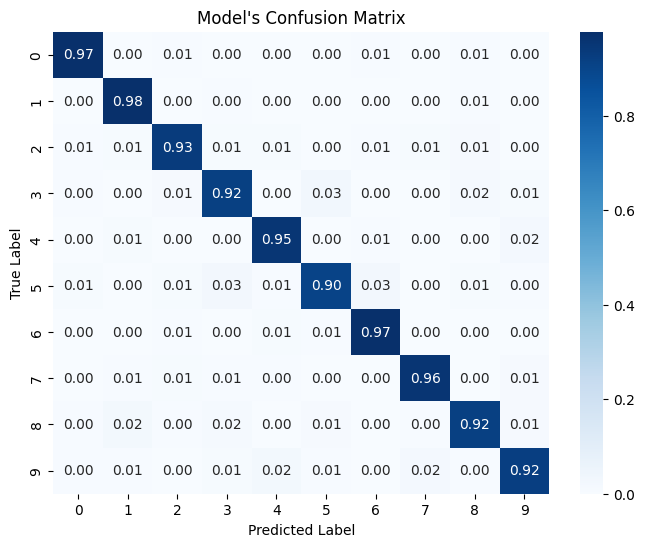

In [58]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt=".2f")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Model's Confusion Matrix")
plt.show()

In [59]:
errors = np.where(y_test_pred != y_test_true)[0]
print(errors[:10])

[ 25  33  52  78  79  90  91 120 144 149]


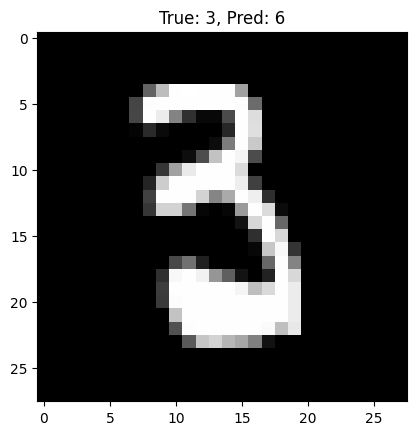

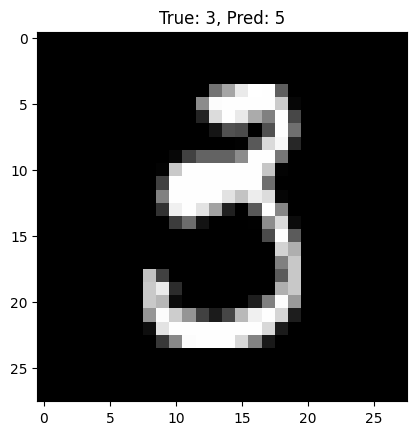

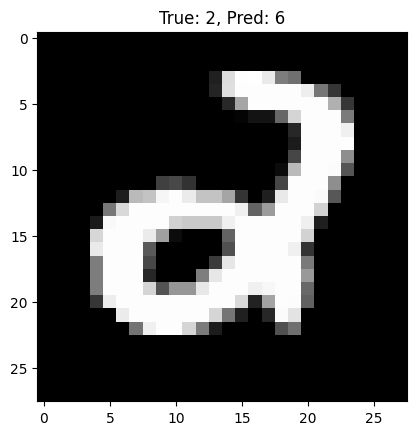

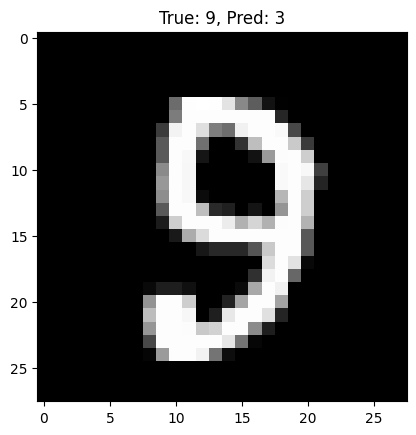

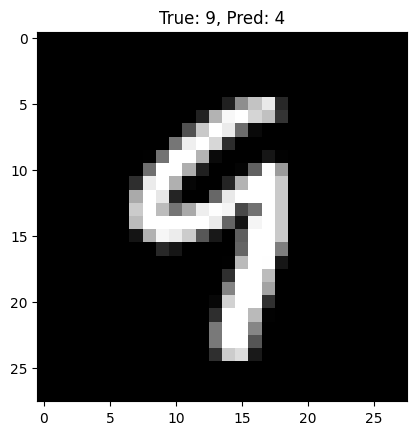

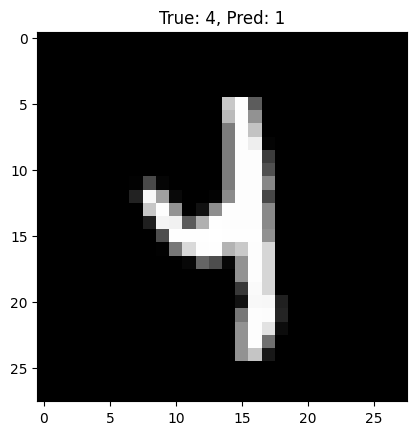

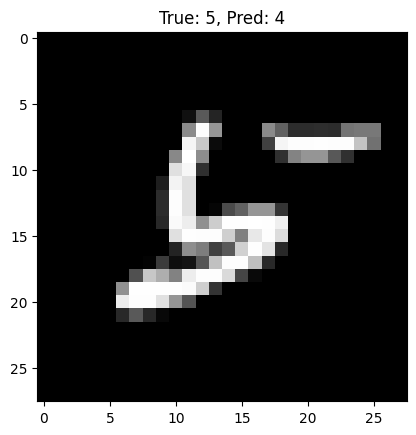

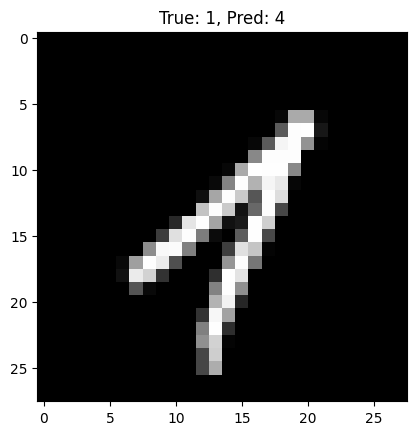

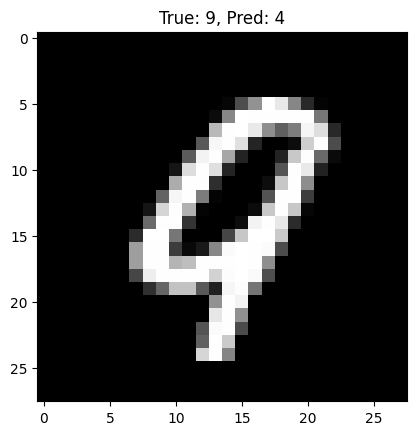

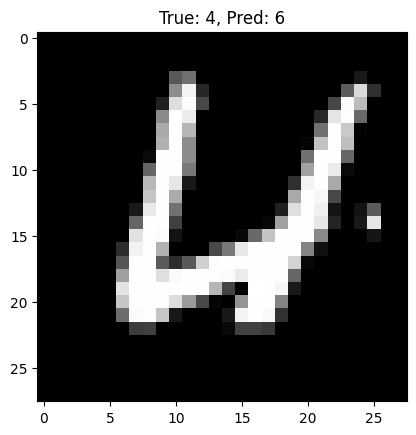

In [60]:
for i in list(errors[0:10]):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test_true[i]}, Pred: {y_test_pred[i]}")
    plt.show()

In [61]:
errors2 = []

for i in range(len(y_test_true)):
    if y_test_pred[i] != y_test_true[i]:
        errors2.append((int(y_test_true[i]), int(y_test_pred[i])))

In [62]:
errors2

[(3, 6),
 (3, 5),
 (2, 6),
 (9, 3),
 (9, 4),
 (4, 1),
 (5, 4),
 (1, 4),
 (9, 4),
 (4, 6),
 (5, 3),
 (8, 1),
 (0, 6),
 (3, 8),
 (5, 8),
 (9, 0),
 (7, 9),
 (0, 8),
 (9, 0),
 (8, 7),
 (8, 3),
 (3, 5),
 (8, 3),
 (3, 8),
 (5, 7),
 (5, 3),
 (9, 7),
 (3, 2),
 (9, 7),
 (7, 1),
 (3, 9),
 (7, 0),
 (9, 4),
 (3, 9),
 (9, 3),
 (6, 2),
 (3, 8),
 (7, 2),
 (3, 9),
 (7, 5),
 (3, 5),
 (9, 7),
 (8, 3),
 (9, 7),
 (9, 7),
 (3, 5),
 (1, 7),
 (5, 6),
 (6, 0),
 (7, 3),
 (6, 5),
 (1, 2),
 (8, 9),
 (7, 0),
 (2, 7),
 (8, 3),
 (2, 8),
 (3, 5),
 (2, 7),
 (4, 9),
 (5, 3),
 (2, 3),
 (4, 9),
 (8, 9),
 (2, 3),
 (4, 8),
 (7, 0),
 (5, 3),
 (9, 4),
 (7, 3),
 (3, 9),
 (6, 4),
 (4, 9),
 (8, 6),
 (8, 9),
 (7, 2),
 (9, 3),
 (9, 1),
 (3, 7),
 (2, 1),
 (9, 4),
 (3, 5),
 (5, 3),
 (9, 1),
 (7, 1),
 (8, 1),
 (2, 6),
 (4, 6),
 (3, 2),
 (7, 9),
 (5, 6),
 (5, 6),
 (8, 5),
 (1, 3),
 (5, 3),
 (0, 6),
 (0, 8),
 (6, 4),
 (7, 4),
 (3, 7),
 (7, 9),
 (2, 4),
 (1, 3),
 (4, 9),
 (3, 5),
 (3, 9),
 (5, 6),
 (2, 3),
 (4, 2),
 (5, 0),
 (3, 9),
 

In [63]:
confusion_pairs = {}

for true, pred in errors2:
    pair = (true, pred)

    if pair not in confusion_pairs:
        confusion_pairs[pair] = 0
    confusion_pairs[pair] += 1

In [67]:
sorted_confusions = sorted(confusion_pairs.items(), key=lambda x:x[1], reverse=True)

for (true, pred), count in sorted_confusions[:10]:
    print(f"True: {true}--> Predicted {pred}: No. of wrong Predictions {count}")

True: 3--> Predicted 5: No. of wrong Predictions 32
True: 5--> Predicted 6: No. of wrong Predictions 26
True: 5--> Predicted 3: No. of wrong Predictions 25
True: 9--> Predicted 4: No. of wrong Predictions 24
True: 8--> Predicted 1: No. of wrong Predictions 24
True: 9--> Predicted 7: No. of wrong Predictions 20
True: 4--> Predicted 9: No. of wrong Predictions 20
True: 3--> Predicted 8: No. of wrong Predictions 16
True: 8--> Predicted 3: No. of wrong Predictions 16
True: 7--> Predicted 9: No. of wrong Predictions 15
